In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [2]:
siames = cv.imread("/Users/miguelcamargorojas/Downloads/siames.jpg")
siames_gray = np.mean(siames, axis=2)
siames_gray.shape

(612, 838)

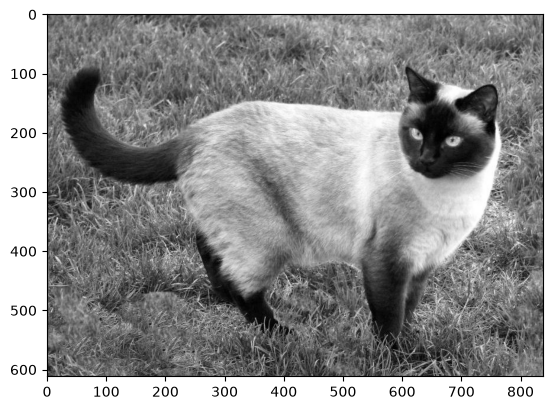

In [ ]:
plt.imshow(siames_gray, cmap='gray')
plt.show()

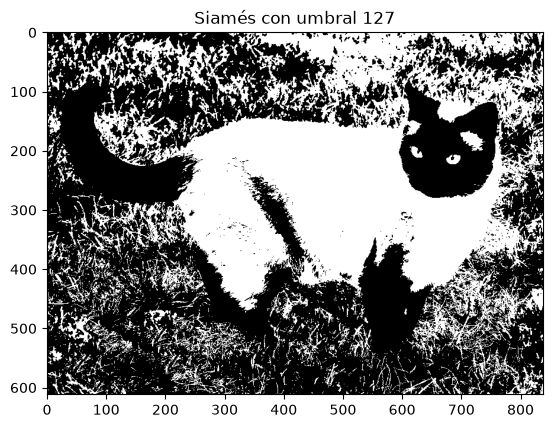

In [11]:
# Umbralización

filas, columnas = siames_gray.shape
siames_umb = siames_gray.copy()
k = 127

# Faltó crear una copia de la imagen para no dañar la original

for f in range(filas):
    for c in range(columnas):
        if siames_gray[f, c] < k:
            siames_umb[f, c] = 0
        else:
            siames_umb[f, c] = 255

plt.imshow(siames_umb, cmap='gray')
plt.title(f"Siamés con umbral {k}")
plt.show()

In [6]:
np.unique(siames_umb)

array([  0., 255.])

In [27]:
k = 127
siames_umb2 = cv.threshold(siames_gray, k, 255, cv.THRESH_BINARY_INV)[1]

In [28]:
np.unique(siames_umb2)

array([  0., 255.])

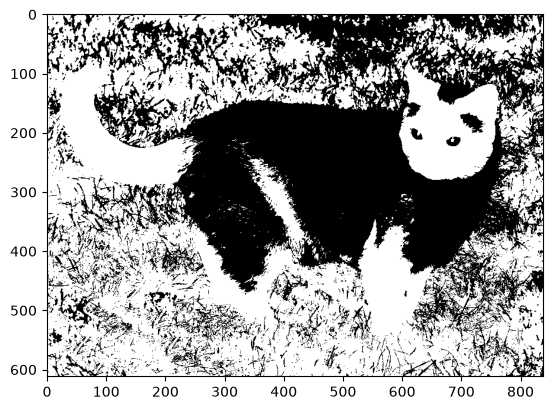

In [29]:
plt.imshow(siames_umb2, cmap='gray')
plt.show()

---
## Transformación logarítimica

s = c log(1 + r)

c = 255/(log (1 + m))

In [38]:
m = np.max(siames_gray)
C = 255 / np.log(1 + m)
C

np.float64(45.98590442833571)

In [30]:
np.pi

3.141592653589793

In [31]:
np.e

2.718281828459045

In [ ]:
# np.log(0)

/var/folders/vr/9n_h2gsj7m16qv6j55xbdp2m0000gn/T/ipykernel_27438/2933082444.py:1: RuntimeWarning: divide by zero encountered in log
  np.log(0)


np.float64(-inf)

In [35]:
np.log(256)

np.float64(5.545177444479562)

uint8


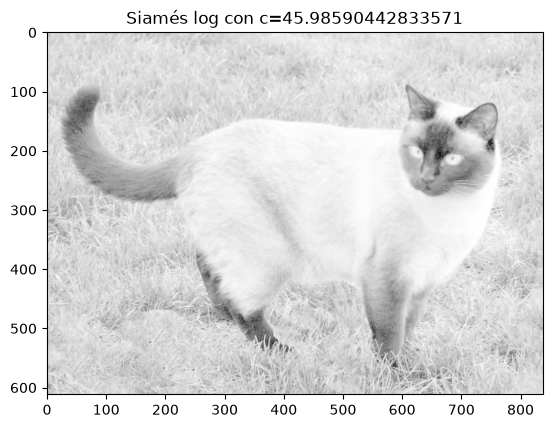

In [ ]:
# log
siames_log = siames_gray.copy()
# siames_log = siames_log.astype(float)
for f in range(filas):
    for c in range(columnas):
        siames_log[f, c] = C * np.log(1 + siames_gray[f, c])

siames_log = siames_log.astype(np.uint8)
print(siames_log.dtype)
plt.imshow(siames_log, cmap='gray')
plt.title(f"Siamés log con c={C}")
plt.show()

In [43]:
np.max(siames_log)

np.uint8(255)

In [44]:
np.min(siames_log)

np.uint8(0)

In [45]:
np.mean(siames_log)

np.float64(214.42502378835385)

In [46]:
np.median(siames_log)

np.float64(220.0)

---
## Gamma

In [47]:
10 ** 2

100

In [48]:
20 ** 2

400

In [57]:
np.astype(np.array(12000), np.uint8)

array(224, dtype=uint8)

In [53]:
800 - 256 

544

In [58]:
12000 % 256

224

uint8


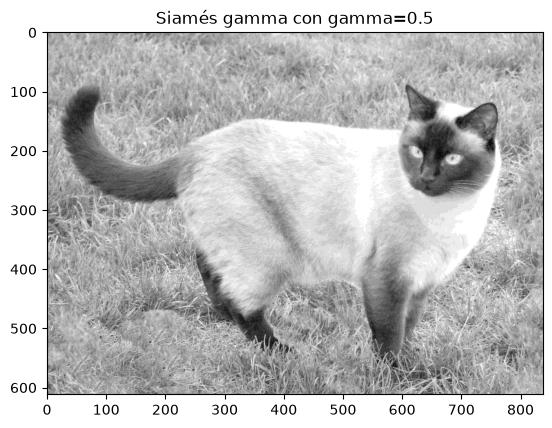

In [62]:
# gamma
gamma = .5
siames_gamma = siames_gray.copy()

for f in range(filas):
    for c in range(columnas):
        siames_gamma[f, c] = siames_gamma[f, c] ** gamma
siames_gamma = siames_gamma.astype(np.uint8)
print(siames_gamma.dtype)
plt.imshow(siames_gamma, cmap='gray')
plt.title(f"Siamés gamma con gamma={gamma}")
plt.show()